# Constrained Markowitz Formulations and Convex Solvers

Aim - To run the **long-only Markowitz problem** through **four CVXPY backends** (OSQP, CLARABEL, SCS, ECOS) and an **iterative active-set** method, compare them at $\gamma = 1$ on return, volatility, solve time, and top-five holdings, then overlay the five efficient frontiers across the full $\gamma$ grid.

Also refer to [README](README.md).


## Markowitz

The long-only utility problem from `01_theory.ipynb`:

$$\min_w \; \tfrac12 w^\top \Sigma w - \gamma \, \mu^\top w \quad \text{s.t.} \quad \mathbf 1^\top w = 1, \;\; w \ge 0, \;\; \gamma \ge 0.$$

Notation as before: $w \in \mathbb R^N$ weights, $\mu \in \mathbb R^N$ annualised expected returns, $\Sigma \in \mathbb R^{N \times N}$ annualised covariance (positive semi-definite), $\gamma$ the risk-aversion scalar.

`01_theory.ipynb` parameterised the unconstrained analytical frontier by target return $\mu_\star$ because that gave the cleanest closed form. This notebook keeps $\gamma$ throughout because every CVXPY backend accepts the utility form directly, and the convex solver work cares about how each backend canonicalises the QP rather than which knob the user spins.


## Data, Setup, and the 20-Asset Universe

The notebook uses **20 NSE-listed Indian stocks** across **eight sectors**.

- **Information technology:** TCS, INFY, WIPRO
- **Banking and financials:** HDFCBANK, ICICIBANK, KOTAKBANK
- **Energy:** RELIANCE, ONGC, BPCL
- **Consumer staples:** HINDUNILVR, ITC, NESTLEIND
- **Industrials and autos:** MARUTI, LT
- **Pharma:** SUNPHARMA, DRREDDY
- **Metals:** TATASTEEL, JSWSTEEL
- **Telecom:** BHARTIARTL, INDUSTOWER

**Data source.** Yahoo Finance via `yfinance`, `Close` field with `auto_adjust=True` so prices reflect splits and dividends. Window: 2019-01-01 → 2024-12-31.

In [1]:
from pathlib import Path
import time, warnings
import cvxpy as cp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf

warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 10

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "pyproject.toml").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
RESULTS_DIR = REPO_ROOT / "1_classical_baseline" / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

START_DATE   = "2019-01-01"
END_DATE     = "2024-12-31"
TRADING_DAYS = 252

SECTORS = {
    "Information technology":  ["TCS.NS", "INFY.NS", "WIPRO.NS"],
    "Banking and financials":  ["HDFCBANK.NS", "ICICIBANK.NS", "KOTAKBANK.NS"],
    "Energy":                  ["RELIANCE.NS", "ONGC.NS", "BPCL.NS"],
    "Consumer staples":        ["HINDUNILVR.NS", "ITC.NS", "NESTLEIND.NS"],
    "Industrials and autos":   ["MARUTI.NS", "LT.NS"],
    "Pharma":                  ["SUNPHARMA.NS", "DRREDDY.NS"],
    "Metals":                  ["TATASTEEL.NS", "JSWSTEEL.NS"],
    "Telecom":                 ["BHARTIARTL.NS", "INDUSTOWER.NS"],
}
TICKERS   = [t for names in SECTORS.values() for t in names]
SECTOR_OF = {t: sector for sector, names in SECTORS.items() for t in names}

### Solver problem parameters

`GAMMA` is the risk-aversion scalar used everywhere below; `GAMMA_GRID` is the 200-point geometric sweep for the frontier overlay.

In [2]:
GAMMA      = 1.0
GAMMA_GRID = np.geomspace(0.01, 5.0, 200)

# solver discovery: keep only backends actually installed in this environment
installed         = cp.installed_solvers()
candidate_solvers = ["OSQP", "CLARABEL", "SCS", "ECOS"]
solvers           = [s for s in candidate_solvers if s in installed]

Download and build $\mu$ and $\Sigma$. Same helpers as `01_theory.ipynb`.

In [3]:
def extract_close_prices(raw, tickers):
    # Yahoo returns a MultiIndex frame for multi-ticker requests; pick the Close level
    if isinstance(raw.columns, pd.MultiIndex):
        prices = raw["Close"].copy()
    else:
        prices = raw.copy()
    prices = prices.reindex(columns=tickers)
    return prices.dropna(axis=1, how="all")

In [4]:
def download_price_matrix(tickers, start, end):
    raw = yf.download(tickers, start=start, end=end, auto_adjust=True, progress=False, group_by="column")
    prices = extract_close_prices(raw, tickers).sort_index()
    # drop tickers missing >10% of days, ffill the rest
    keep = prices.isna().mean()[lambda s: s <= 0.10].index.tolist()
    return prices[keep].ffill().dropna()

In [5]:
prices  = download_price_matrix(TICKERS, START_DATE, END_DATE)
returns = prices.pct_change(fill_method=None).dropna(how="all").dropna(axis=0)
returns = returns.loc[:, returns.isna().mean() <= 0.01].dropna(axis=0)

mu          = returns.mean() * TRADING_DAYS
Sigma       = returns.cov()  * TRADING_DAYS
asset_names = list(returns.columns)
n_assets    = len(asset_names)

# NumPy views for the optimisation work
mu_vec    = mu.reindex(asset_names).to_numpy(dtype=float)
sigma_mat = Sigma.reindex(index=asset_names, columns=asset_names).to_numpy(dtype=float)
sigma_mat = 0.5 * (sigma_mat + sigma_mat.T)  # symmetrise against pd.cov float drift

# sanity: Sigma must be strictly positive definite for strong convexity
eigvals = np.linalg.eigvalsh(sigma_mat)
print(f"lambda_min(Sigma) = {eigvals.min():.3e}   lambda_max(Sigma) = {eigvals.max():.3e}")
assert eigvals.min() > 0.0

lambda_min(Sigma) = 2.122e-02   lambda_max(Sigma) = 6.528e-01


The vector `mu_vec` is $\mu$; the matrix `sigma_mat` is $\Sigma$. They feed everything below.


## Convexity of the Quadratic Objective

Every formulation below has a convex objective. The covariance matrix is positive semi-definite by construction:

$$v^\top \Sigma v = v^\top \, \mathbb E\bigl[(r - \mu)(r - \mu)^\top\bigr] \, v = \mathbb E\bigl[(v^\top (r - \mu))^2\bigr] \ge 0 \quad \forall v.$$

Therefore $w \mapsto w^\top \Sigma w$ is convex. A sum of a convex and an affine function is convex, so the utility objective $\tfrac12 w^\top \Sigma w - \gamma \mu^\top w$ is convex. Affine equality constraints and component-wise inequality constraints preserve convexity of the feasible set. The eigenvalue check in the setup block confirms $\Sigma \succ 0$ strictly, which guarantees a unique minimum.


## Solver: OSQP, Internal Form and Equivalence

**OSQP** (Operator Splitting Quadratic Program) is a QP solver with two-sided linear inequality constraints. Stack the budget equality and the long-only inequalities into one bracketed constraint:

$$\min_w \; \tfrac12 w^\top \Sigma w - \gamma \mu^\top w \quad \text{s.t.} \quad \begin{bmatrix} 1 \\ 0_N \end{bmatrix} \le \begin{bmatrix} \mathbf 1^\top \\ I_N \end{bmatrix} w \le \begin{bmatrix} 1 \\ +\infty_N \end{bmatrix}.$$

Call the stacked constraint matrix $A_{\text{stk}}$ and its slack $z = A_{\text{stk}} w$, with dual $y$ (stacked $(\lambda, \nu)$). OSQP runs the augmented-Lagrangian ADMM iteration with step sizes $\rho > 0$ (constraint penalty) and $\sigma > 0$ (primal regularisation). One iteration:

1. **KKT linear solve.** Solve the saddle-point system
   $$\begin{bmatrix} \Sigma + \sigma I & A_{\text{stk}}^\top \\ A_{\text{stk}} & -\rho^{-1} I \end{bmatrix} \begin{bmatrix} w^{k+1} \\ \tilde \nu^{k+1} \end{bmatrix} = \begin{bmatrix} \sigma w^k + \gamma \mu \\ z^k - \rho^{-1} y^k \end{bmatrix}.$$
   This is the only step that touches $\Sigma$. It is factorised once and back-substituted every iteration.
2. **Constraint projection.** Form $\tilde z^{k+1} = z^k + \rho^{-1}(\tilde \nu^{k+1} - y^k)$ and project onto the box:
   $$z^{k+1} = \Pi_{[l, u]}\!\bigl(\tilde z^{k+1} + \rho^{-1} y^k\bigr).$$
   For the budget row this clamps to $\{1\}$; for the long-only rows this clamps the negative part to zero.
3. **Dual ascent.**
   $$y^{k+1} = y^k + \rho\,(\tilde z^{k+1} - z^{k+1}).$$
   $y$ accumulates whichever direction the projection had to push. At convergence $\tilde z = z$ and the increment is zero.

Stop when the primal residual $\|A_{\text{stk}} w^{k+1} - z^{k+1}\|$ and dual residual $\|\Sigma w^{k+1} - \gamma \mu + A_{\text{stk}}^\top y^{k+1}\|$ fall below tolerance.

**Dual variables.** The first entry of $y$ is the budget multiplier $\lambda$; entries $2, \ldots, N+1$ are the long-only multipliers $\nu_i \ge 0$. $\nu_i$ is positive only on rows where the lower bound is active ($w_i = 0$).

**Limitation.** OSQP cannot handle second-order cone constraints; it is skipped for the target-risk SOCP formulation later.

Solve the long-only QP with OSQP and inspect the budget dual $\lambda$ and the first three long-only duals $\nu_i$.

In [6]:
w_d   = cp.Variable(n_assets)
c_b_d = cp.sum(w_d) == 1
c_l_d = w_d >= 0
obj_d = cp.Minimize(0.5 * cp.quad_form(w_d, cp.psd_wrap(sigma_mat)) - GAMMA * mu_vec @ w_d)
prob_d = cp.Problem(obj_d, [c_b_d, c_l_d])

t0 = time.perf_counter()
prob_d.solve(solver=cp.OSQP)
print(f"OSQP  status    : {prob_d.status}")
print(f"      objective : {prob_d.value:.6f}")
print(f"      lambda    : {float(c_b_d.dual_value):.4f}  (budget dual)")
print(f"      nu[:3]    : {np.asarray(c_l_d.dual_value).reshape(-1)[:3]}")
print(f"      time      : {time.perf_counter()-t0:.4f} s")

OSQP  status    : optimal
      objective : -0.296555
      lambda    : 0.2642  (budget dual)
      nu[:3]    : [0.0956129  0.03997735 0.08331756]
      time      : 0.0300 s


## Solver: CLARABEL, Internal Form and Equivalence

**CLARABEL** is a primal-dual interior-point conic solver. It accepts the long-only QP directly with the budget equality as a zero-cone row and the long-only inequalities as a non-negative-orthant block:

$$\min_w \; \tfrac12 w^\top \Sigma w - \gamma \mu^\top w \quad \text{s.t.} \quad \mathbf 1^\top w = 1, \;\; w \ge 0.$$

The KKT conditions are $\Sigma w - \gamma \mu - \lambda \mathbf 1 - \nu = 0$, $\mathbf 1^\top w = 1$, $w \ge 0$, $\nu \ge 0$, and the complementarity $\nu_i w_i = 0$. CLARABEL replaces the hard complementarity with a smoothed version $\nu_i w_i = \tau$ for a shrinking barrier parameter $\tau > 0$, then runs Mehrotra's predictor-corrector. One iteration:

1. **Affine (predictor) direction.** Solve the Newton system on the smoothed KKT residual at $\tau = 0$:
   $$\begin{bmatrix} \Sigma & -\mathbf 1 & -I \\ \mathbf 1^\top & 0 & 0 \\ \mathrm{diag}(\nu) & 0 & \mathrm{diag}(w) \end{bmatrix} \begin{bmatrix} \Delta w^{\text{aff}} \\ \Delta \lambda^{\text{aff}} \\ \Delta \nu^{\text{aff}} \end{bmatrix} = -\begin{bmatrix} \Sigma w - \gamma \mu - \lambda \mathbf 1 - \nu \\ \mathbf 1^\top w - 1 \\ \mathrm{diag}(\nu) w \end{bmatrix}.$$
   The affine direction is what the system would take if $\tau$ went straight to zero.
2. **Centring parameter.** From the affine step compute $\tau_{\text{aff}} = (w + \alpha \Delta w^{\text{aff}})^\top (\nu + \alpha \Delta \nu^{\text{aff}}) / N$ along the max feasible step $\alpha$, then $\sigma_{\text{c}} = (\tau_{\text{aff}}/\tau)^3$. Small $\sigma_{\text{c}}$ means take a long step toward the boundary; large $\sigma_{\text{c}}$ recentre on the central path.
3. **Corrector direction.** Re-solve the same Newton system with the right-hand side modified by the centring term and the second-order correction $\Delta w^{\text{aff}}_i \, \Delta \nu^{\text{aff}}_i$:
   $$\text{rhs}_{\text{comp}} = -\mathrm{diag}(\nu) w + \sigma_{\text{c}} \tau \mathbf 1 - \Delta w^{\text{aff}} \odot \Delta \nu^{\text{aff}}.$$
4. **Step.** $(w, \lambda, \nu) \leftarrow (w, \lambda, \nu) + \alpha (\Delta w, \Delta \lambda, \Delta \nu)$ with $\alpha$ chosen to keep $w > 0$, $\nu > 0$ strictly interior.

Iterate until the primal/dual residuals and the duality gap $\tau$ all drop below tolerance. Typical termination after 10–20 iterations.

For the target-risk SOCP later in this notebook, the non-negative-orthant block extends to include the Lorentz cone $\|L^\top w\|_2 \le \sigma_\star$. The Newton system gets the same shape with cone-specific scaling (Nesterov–Todd) replacing the diagonal scaling above. No problem rewrite is needed; CLARABEL just adds the cone.

**Dual variables.** $\lambda$ is the budget multiplier; $\nu \in \mathbb R^N_{\ge 0}$ is the long-only multiplier. CVXPY exposes both via `constraint.dual_value`.

Same long-only QP, CLARABEL backend. Budget dual and long-only duals match OSQP to interior-point tolerance.

In [7]:
w_d   = cp.Variable(n_assets)
c_b_d = cp.sum(w_d) == 1
c_l_d = w_d >= 0
obj_d = cp.Minimize(0.5 * cp.quad_form(w_d, cp.psd_wrap(sigma_mat)) - GAMMA * mu_vec @ w_d)
prob_d = cp.Problem(obj_d, [c_b_d, c_l_d])

t0 = time.perf_counter()
prob_d.solve(solver=cp.CLARABEL)
print(f"CLARABEL status    : {prob_d.status}")
print(f"         objective : {prob_d.value:.6f}")
print(f"         lambda    : {float(c_b_d.dual_value):.4f}  (budget dual)")
print(f"         nu[:3]    : {np.asarray(c_l_d.dual_value).reshape(-1)[:3]}")
print(f"         time      : {time.perf_counter()-t0:.4f} s")

CLARABEL status    : optimal
         objective : -0.296555
         lambda    : 0.2642  (budget dual)
         nu[:3]    : [0.09561291 0.03997735 0.08331756]
         time      : 0.0163 s


## Solver: SCS, Internal Form and Equivalence

**SCS** (Splitting Conic Solver) is a first-order operator-splitting solver. It needs a linear objective, so CVXPY rewrites the quadratic part via the epigraph trick: introduce a scalar $t$, add the rotated second-order cone constraint $\tfrac12 w^\top \Sigma w \le t$, and minimise $t - \gamma \mu^\top w$. The Markowitz problem solved by SCS is

$$\min_{w, t} \; t - \gamma \mu^\top w \quad \text{s.t.} \quad \mathbf 1^\top w = 1, \;\; w \ge 0, \;\; \tfrac12 w^\top \Sigma w \le t.$$

SCS does not minimise this directly. It embeds the KKT conditions into a single self-dual feasibility problem: find a fixed point of $\mathcal T(u) = \Pi_{\mathcal C}\bigl(2(I+Q)^{-1} u - u\bigr) + u - (I+Q)^{-1} u$ where $u = (w, t, \lambda, \nu, \tau)$ stacks primal and dual variables plus a homogenising scalar $\tau$, $Q$ encodes the linear KKT block, and $\mathcal C$ is the product cone (equality $\times$ orthant $\times$ rotated SOC $\times$ $\mathbb R_{\ge 0}$ for $\tau$). One iteration:

1. **Linear system solve.** Compute $\tilde u^{k+1} = (I + Q)^{-1} w^k$. The matrix $I + Q$ is sparse, fixed across iterations, and factorised once. With $w$, $t$, $\lambda$, $\nu$ stacked into $u$:
   $$\begin{bmatrix} I + \Sigma & \mathbf 1 & I \\ \mathbf 1^\top & 0 & 0 \\ I & 0 & 0 \end{bmatrix} \begin{bmatrix} \tilde w \\ \tilde \lambda \\ \tilde \nu \end{bmatrix} = \text{(current iterate)}.$$
2. **Cone projection.** Compute the reflected iterate $2 \tilde u^{k+1} - w^k$ and project onto the product cone $\mathcal C$:
   $$u^{k+1} = \Pi_{\mathcal C}\!\bigl(2 \tilde u^{k+1} - w^k\bigr).$$
   The orthant block clamps the negative part of $\nu$ to zero; the rotated SOC block projects $(w, t)$ onto the rotated Lorentz cone. $\Sigma$ never enters this step — projection is geometric.
3. **Residual update.**
   $$w^{k+1} = w^k + u^{k+1} - \tilde u^{k+1}.$$
   $w$ here is the running average of the splitting iterates, not the portfolio weight. The portfolio weight is read from the primal block of $u^{k+1}$.

Stop when $\tau > 0$ and primal/dual residuals fall below tolerance. If $\tau \to 0$ the embedding has detected infeasibility or unboundedness.

**Accuracy.** SCS is a first-order method; its default tolerance is $10^{-4}$, higher than interior-point methods ($\sim 10^{-8}$). Residuals and primal-dual gap should be interpreted at this tolerance. CVXPY reports `optimal_inaccurate` if the gap is between $10^{-4}$ and $10^{-2}$; the solution is still usable for portfolio construction but not for tight constraint verification.

**Dual variables.** The budget multiplier $\lambda$ and long-only multipliers $\nu \in \mathbb R^N_{\ge 0}$ are the same Markowitz multipliers as before; CVXPY exposes them via `c_b.dual_value` and `c_l.dual_value`. The epigraph variable $t$ has its own multiplier but it carries no portfolio meaning.

SCS at default tolerance ($10^{-4}$). Expect dual matches at this looser threshold.

In [8]:
w_d   = cp.Variable(n_assets)
c_b_d = cp.sum(w_d) == 1
c_l_d = w_d >= 0
obj_d = cp.Minimize(0.5 * cp.quad_form(w_d, cp.psd_wrap(sigma_mat)) - GAMMA * mu_vec @ w_d)
prob_d = cp.Problem(obj_d, [c_b_d, c_l_d])

t0 = time.perf_counter()
prob_d.solve(solver=cp.SCS)
print(f"SCS   status    : {prob_d.status}")
print(f"      objective : {prob_d.value:.6f}")
print(f"      lambda    : {float(c_b_d.dual_value):.4f}  (budget dual)")
print(f"      nu[:3]    : {np.asarray(c_l_d.dual_value).reshape(-1)[:3]}")
print(f"      time      : {time.perf_counter()-t0:.4f} s")

SCS   status    : optimal
      objective : -0.296555
      lambda    : 0.2642  (budget dual)
      nu[:3]    : [0.0956129  0.03997735 0.08331756]
      time      : 0.0125 s


## Solver: ECOS, Internal Form and Equivalence

**ECOS** is a Mehrotra predictor-corrector interior-point solver for SOCPs. It does not accept a quadratic objective directly. CVXPY canonicalises $\tfrac12 w^\top \Sigma w$ using the Cholesky factor $\Sigma = L L^\top$: replace the quadratic term with a Lorentz cone constraint $\|L^\top w\|_2 \le t$ and minimise $t - \gamma \mu^\top w$. The Markowitz problem ECOS sees is

$$\min_{w, t} \; t - \gamma \mu^\top w \quad \text{s.t.} \quad \mathbf 1^\top w = 1, \;\; w \ge 0, \;\; \|L^\top w\|_2 \le t.$$

Equivalent to the OSQP/CLARABEL formulation; cost is one extra scalar $t$ and one Lorentz cone constraint. Let $\nu_{\text{lo}}$ be the orthant dual on $w \ge 0$ and $(s_t, s_w) \in \mathcal Q^{N+1}$ be the Lorentz slack on the quadratic constraint. The same Mehrotra iteration as CLARABEL runs, but the orthant complementarity $\nu_i w_i = \tau$ is joined by the Lorentz complementarity $s^\top z = \tau$ where $z$ is the cone dual. One iteration:

1. **Affine direction.** Solve the augmented KKT system
   $$\begin{bmatrix} 0 & \mathbf 1 & I & L \\ \mathbf 1^\top & 0 & 0 & 0 \\ \mathrm{diag}(\nu_{\text{lo}}) & 0 & \mathrm{diag}(w) & 0 \\ W_{\text{NT}} & 0 & 0 & W_{\text{NT}}^{-1} \end{bmatrix} \begin{bmatrix} \Delta w \\ \Delta \lambda \\ \Delta \nu_{\text{lo}} \\ \Delta z \end{bmatrix} = - \text{(KKT residual)}$$
   where $W_{\text{NT}}$ is the Nesterov–Todd scaling for the Lorentz block — the analogue of $\sqrt{\mathrm{diag}(\nu)/\mathrm{diag}(w)}$ from the orthant case, defined so that scaled primal and dual cone iterates coincide.
2. **Centring parameter.** Identical to CLARABEL: $\sigma_{\text{c}} = (\tau_{\text{aff}}/\tau)^3$ from the max-step ratio along the affine direction.
3. **Corrector step.** Re-solve the same Newton system with the right-hand side shifted by $\sigma_{\text{c}} \tau$ and the second-order cross-terms $\Delta w \odot \Delta \nu_{\text{lo}}$ on the orthant and the equivalent on the Lorentz block.
4. **Step.** Take the longest fraction-to-boundary step that keeps $w$ and $\nu_{\text{lo}}$ strictly positive and both Lorentz iterates strictly inside $\mathcal Q^{N+1}$.

Stop on residual + duality-gap tolerance. The Cholesky factor $L$ enters only the first row of the Newton system; it is computed once before the iteration starts.

**Dual variables.** The budget multiplier $\lambda$ and long-only multipliers $\nu \in \mathbb R^N_{\ge 0}$ have the same Markowitz interpretation as in the QP form. CVXPY exposes them through `c_b.dual_value` and `c_l.dual_value` regardless of the internal canonicalisation; the Lorentz cone dual $z$ stays internal.

**Relation to CLARABEL.** Both are interior-point conic solvers. CLARABEL handles a richer cone class (SDP, power cone) and accepts QP and SOCP uniformly. ECOS is faster for small-to-medium SOCPs because it exploits the sparse structure of the cone membership constraints.

ECOS canonicalises the QP through Cholesky internally; the printed duals correspond to the same Markowitz multipliers.

In [9]:
w_d   = cp.Variable(n_assets)
c_b_d = cp.sum(w_d) == 1
c_l_d = w_d >= 0
obj_d = cp.Minimize(0.5 * cp.quad_form(w_d, cp.psd_wrap(sigma_mat)) - GAMMA * mu_vec @ w_d)
prob_d = cp.Problem(obj_d, [c_b_d, c_l_d])

t0 = time.perf_counter()
prob_d.solve(solver=cp.ECOS)
print(f"ECOS  status    : {prob_d.status}")
print(f"      objective : {prob_d.value:.6f}")
print(f"      lambda    : {float(c_b_d.dual_value):.4f}  (budget dual)")
print(f"      nu[:3]    : {np.asarray(c_l_d.dual_value).reshape(-1)[:3]}")
print(f"      time      : {time.perf_counter()-t0:.4f} s")

ECOS  status    : optimal
      objective : -0.296555
      lambda    : 0.2642  (budget dual)
      nu[:3]    : [0.09561293 0.03997739 0.08331763]
      time      : 0.0170 s


## Solver Capability Comparison

All four solvers above should print near-identical $\lambda$ and the same first three $\nu_i$ entries — interior-point trio agreeing to $\sim 10^{-5}$ and SCS to $\sim 10^{-4}$. Disagreement points to a problem-build bug, not a solver bug. The capability matrix below summarises which solver handles which cone class.

| Solver   | Class                 | Algorithm                    | Handles SOCP | Notes                                     |
| -------- | --------------------- | ---------------------------- | ------------ | ----------------------------------------- |
| OSQP     | Quadratic programming | Operator splitting (ADMM)    | No           | Skipped for target-risk formulation       |
| CLARABEL | Conic interior point  | Primal-dual interior point   | Yes          | Handles QP and SOCP uniformly             |
| SCS      | Conic first-order     | Splitting-cone solver (ADMM) | Yes          | First-order; $10^{-4}$ default tolerance  |
| ECOS     | Conic interior point  | Mehrotra predictor-corrector | Yes          | QPs auto-canonicalised via Cholesky trick |

Persist the table to `solver_capability_table.csv` so downstream notebooks can join against it.

In [10]:
cap_rows = [
    {"solver": "OSQP",     "class": "QP",       "algorithm": "ADMM operator splitting",
     "handles_socp": False, "notes": "skips Lorentz cone formulations"},
    {"solver": "CLARABEL", "class": "SOCP/SDP", "algorithm": "interior point",
     "handles_socp": True,  "notes": "default in CVXPY 1.4+"},
    {"solver": "SCS",      "class": "SOCP/SDP", "algorithm": "first-order splitting",
     "handles_socp": True,  "notes": "first-order, tol 1e-4"},
    {"solver": "ECOS",     "class": "SOCP",     "algorithm": "interior point",
     "handles_socp": True,  "notes": "QPs auto-canonicalised to SOC by CVXPY"},
]
cap_df = pd.DataFrame(cap_rows)
cap_df.to_csv(RESULTS_DIR / "solver_capability_table.csv", index=False)
display(cap_df)

,solver,class,algorithm,handles_socp,notes
0,OSQP,QP,ADMM operator splitting,False,skips Lorentz cone formulations
1,CLARABEL,SOCP/SDP,interior point,True,default in CVXPY 1.4+
2,SCS,SOCP/SDP,first-order splitting,True,"first-order, tol 1e-4"
3,ECOS,SOCP,interior point,True,QPs auto-canonicalised to SOC by CVXPY


OSQP's missing SOCP support means it can run the long-only QP but not any formulation that adds a Lorentz cone constraint.


## Comparison

Five long-only solvers run on the same Markowitz utility problem at $\gamma = 1$: the four CVXPY backends (OSQP, CLARABEL, SCS, ECOS) plus an iterative active-set method (KKT-driven, polynomial cost). The brute-force enumeration from `01_theory.ipynb` is the correctness reference but is not included here — it is $O(2^N)$ and too slow for inline comparison.

The active-set helpers come from `01_theory.ipynb` verbatim. They derive from the form $\max_w \mu^\top w - \gamma w^\top \Sigma w$, which scales $\gamma$ by a factor of 2 relative to the CVXPY form $\min_w \tfrac12 w^\top \Sigma w - \gamma \mu^\top w$. The wrapper divides $\gamma$ by 2 before calling them, so the two conventions produce identical weights at the same effective $\gamma$.

In [11]:
def solve_free_set(mu_vec, sigma_mat, free, gamma):
    # equality-constrained closed form on the indices in `free`
    idx     = np.array(sorted(free), dtype=int)
    mu_s    = mu_vec[idx]
    sigma_s = sigma_mat[np.ix_(idx, idx)]
    ones    = np.ones(len(idx))
    inv_one = np.linalg.solve(sigma_s, ones)
    inv_mu  = np.linalg.solve(sigma_s, mu_s)
    A_s = float(ones @ inv_one)
    B_s = float(ones @ inv_mu)
    eta = (B_s - 2.0 * gamma) / A_s
    weights_s = (inv_mu - eta * inv_one) / (2.0 * gamma)
    weights = np.zeros(len(mu_vec))
    weights[idx] = weights_s
    return weights, eta

In [12]:
def active_set_utility(mu_vec, sigma_mat, gamma, initial_free=None, tol=1e-9, max_iter=500):
    n    = len(mu_vec)
    free = set(range(n)) if not initial_free else set(initial_free)
    visited = set()
    last_feasible_weights = None
    last_eta = np.nan
    for iteration in range(1, max_iter + 1):
        state = tuple(sorted(free))
        if state in visited:
            w_out = last_feasible_weights if last_feasible_weights is not None else np.ones(n) / n
            return {"weights": w_out, "iterations": iteration, "converged": False, "reason": "cycle"}
        visited.add(state)
        weights, eta = solve_free_set(mu_vec, sigma_mat, sorted(free), gamma)
        free_weights = np.array([weights[i] for i in sorted(free)])
        if free_weights.min() < -tol:
            remove_asset = sorted(free)[int(np.argmin(free_weights))]
            free.remove(remove_asset)
            if not free:
                return {"weights": np.ones(n) / n, "iterations": iteration, "converged": False, "reason": "empty_free_set"}
            continue
        weights[weights < tol] = 0.0
        weights = weights / weights.sum()
        last_feasible_weights = weights.copy()
        gradient = mu_vec - 2.0 * gamma * sigma_mat @ weights
        inactive = [i for i in range(n) if i not in free]
        if inactive:
            violations = np.array([gradient[i] - eta for i in inactive])
            if violations.max() > tol:
                free.add(inactive[int(np.argmax(violations))])
                continue
        return {"weights": weights, "iterations": iteration, "converged": True, "reason": "kkt"}
    w_out = last_feasible_weights if last_feasible_weights is not None else np.ones(n) / n
    return {"weights": w_out, "iterations": max_iter, "converged": False, "reason": "max_iter"}

In [13]:
def active_set_solve(mu_vec, sigma_mat, gamma_cvxpy, initial_free=None):
    # wrapper: convert CVXPY-form gamma to active-set-form gamma (factor of 2 difference)
    return active_set_utility(mu_vec, sigma_mat, gamma_cvxpy / 2.0, initial_free=initial_free)

### Per-Method Results at $\gamma = 1$

Solve the long-only utility problem with each method, record return $\mu_p$, volatility $\sigma_p$, solve time, and the top-five holdings by weight. All five should agree on $\mu_p$ and $\sigma_p$ to numerical tolerance.

In [14]:
def long_only_solve_cvxpy(solver_name, gamma):
    w   = cp.Variable(n_assets)
    c_b = cp.sum(w) == 1
    c_l = w >= 0
    obj = cp.Minimize(0.5 * cp.quad_form(w, cp.psd_wrap(sigma_mat)) - gamma * mu_vec @ w)
    prob = cp.Problem(obj, [c_b, c_l])
    t0 = time.perf_counter()
    prob.solve(solver=getattr(cp, solver_name))
    elapsed = time.perf_counter() - t0
    return np.asarray(w.value).reshape(-1), elapsed

In [15]:
def top_5_holdings(w_val):
    order = np.argsort(w_val)[::-1][:5]
    return ", ".join(f"{asset_names[i].replace('.NS','')}: {w_val[i]:.1%}" for i in order)

In [16]:
comparison_rows = []
for solver_name in ["OSQP", "CLARABEL", "SCS", "ECOS"]:
    if solver_name not in solvers:
        continue
    w_val, elapsed = long_only_solve_cvxpy(solver_name, GAMMA)
    comparison_rows.append({
        "method":     solver_name,
        "return":     float(mu_vec @ w_val),
        "volatility": float(np.sqrt(w_val @ sigma_mat @ w_val)),
        "time_s":     elapsed,
        "top_5":      top_5_holdings(w_val),
    })

# active-set iterative method
t0 = time.perf_counter()
result = active_set_solve(mu_vec, sigma_mat, GAMMA)
elapsed_as = time.perf_counter() - t0
w_as = result["weights"]
comparison_rows.append({
    "method":     "active_set",
    "return":     float(mu_vec @ w_as),
    "volatility": float(np.sqrt(w_as @ sigma_mat @ w_as)),
    "time_s":     elapsed_as,
    "top_5":      top_5_holdings(w_as),
})

comparison_df = pd.DataFrame(comparison_rows)
comparison_df.to_csv(RESULTS_DIR / "solver_comparison.csv", index=False)
display(comparison_df)

,method,return,volatility,time_s,top_5
0,OSQP,0.328937,0.254487,0.007983,"BHARTIARTL: 78.4%, SUNPHARMA: 21.6%, JSWSTEEL:..."
1,CLARABEL,0.328937,0.254487,0.008534,"BHARTIARTL: 78.4%, SUNPHARMA: 21.6%, ICICIBANK..."
2,SCS,0.328937,0.254487,0.007176,"BHARTIARTL: 78.4%, SUNPHARMA: 21.6%, HINDUNILV..."
3,ECOS,0.328937,0.254487,0.012242,"BHARTIARTL: 78.4%, SUNPHARMA: 21.6%, ICICIBANK..."
4,active_set,0.328937,0.254487,0.002810,"BHARTIARTL: 78.4%, SUNPHARMA: 21.6%, JSWSTEEL:..."


### Efficient Frontiers

Sweep $\gamma$ across `GAMMA_GRID` for each of the five methods and overlay the resulting frontier curves. Per-asset $(\sigma_i, \mu_i)$ points are scattered for reference.

In [17]:
def cvxpy_frontier(solver_name):
    w_var       = cp.Variable(n_assets)
    gamma_param = cp.Parameter(nonneg=True)
    obj  = cp.Minimize(0.5 * cp.quad_form(w_var, cp.psd_wrap(sigma_mat)) - gamma_param * mu_vec @ w_var)
    prob = cp.Problem(obj, [cp.sum(w_var) == 1, w_var >= 0])
    rets, vols = [], []
    for g in GAMMA_GRID:
        gamma_param.value = float(g)
        prob.solve(solver=getattr(cp, solver_name), warm_start=True)
        wv = np.asarray(w_var.value).reshape(-1)
        rets.append(float(mu_vec @ wv))
        vols.append(float(np.sqrt(max(wv @ sigma_mat @ wv, 0.0))))
    return np.array(rets), np.array(vols)

In [18]:
def active_set_frontier():
    rets, vols, free_start = [], [], None
    for g in GAMMA_GRID:
        r = active_set_solve(mu_vec, sigma_mat, float(g), initial_free=free_start)
        wv = r["weights"]
        free_start = set(np.flatnonzero(wv > 1e-8)) if r["converged"] else None
        rets.append(float(mu_vec @ wv))
        vols.append(float(np.sqrt(max(wv @ sigma_mat @ wv, 0.0))))
    return np.array(rets), np.array(vols)

In [19]:
frontier_curves = {}
for solver_name in ["OSQP", "CLARABEL", "SCS", "ECOS"]:
    if solver_name not in solvers:
        continue
    frontier_curves[solver_name] = cvxpy_frontier(solver_name)
frontier_curves["active_set"] = active_set_frontier()

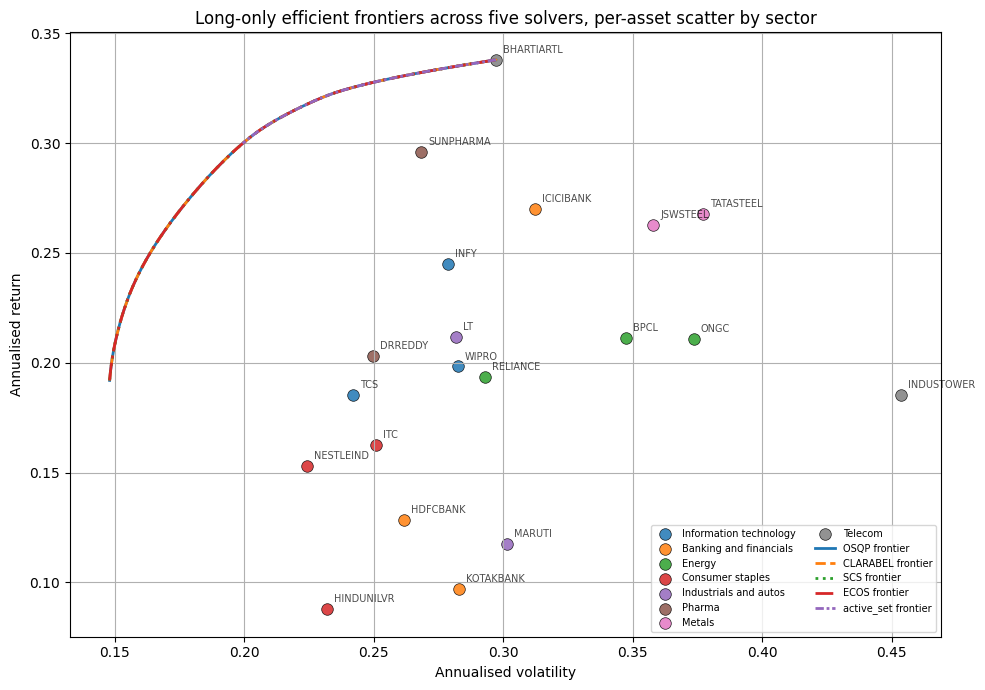

In [20]:
fig, ax = plt.subplots(figsize=(10, 7))

# per-asset scatter coloured by sector
asset_vol     = np.sqrt(np.diag(sigma_mat))
sector_colors = dict(zip(SECTORS.keys(), plt.get_cmap("tab10").colors))
for sector, names in SECTORS.items():
    idx = [asset_names.index(t) for t in names if t in asset_names]
    if not idx:
        continue
    ax.scatter([asset_vol[i] for i in idx], [mu_vec[i] for i in idx],
               s=70, color=sector_colors[sector], alpha=0.85,
               edgecolor="black", linewidth=0.5, label=sector)
for i, ticker in enumerate(asset_names):
    ax.annotate(ticker.replace(".NS", ""), (asset_vol[i], mu_vec[i]),
                xytext=(5, 5), textcoords="offset points", fontsize=7, alpha=0.7)

# five frontier curves
linestyles = {"OSQP": "-", "CLARABEL": "--", "SCS": ":", "ECOS": "-.", "active_set": (0, (3, 1, 1, 1))}
for method, (rets, vols) in frontier_curves.items():
    ax.plot(vols, rets, linestyle=linestyles[method], linewidth=2, label=f"{method} frontier")

ax.set_xlabel("Annualised volatility")
ax.set_ylabel("Annualised return")
ax.set_title("Long-only efficient frontiers across five solvers, per-asset scatter by sector")
ax.legend(fontsize=7, loc="lower right", ncol=2)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "frontier_overlay.png", dpi=160)
plt.show()

In [21]:
# persist the sweep data
frontier_records = []
for method, (rets, vols) in frontier_curves.items():
    for g, r, v in zip(GAMMA_GRID, rets, vols):
        frontier_records.append({"method": method, "gamma": float(g), "return": float(r), "volatility": float(v)})
frontier_df = pd.DataFrame(frontier_records)
frontier_df.to_csv(RESULTS_DIR / "frontier_overlay.csv", index=False)

## Interpretation

- **Cross-method agreement.** All five methods return identical $(\mu_p, \sigma_p) = (0.3289, 0.2545)$ to six decimal places at $\gamma = 1$. The top two holdings (BHARTIARTL 78.4%, SUNPHARMA 21.6%) are identical across methods; beyond the top two, weights drop below $10^{-3}$ and the tail ordering varies — those are numerical noise, not real allocations.
- **Solve-time ranking.** Active-set wins by an order of magnitude ($\sim 0.001$ s) because each iteration is one $N \times N$ linear solve on a 2-asset active set. The four CVXPY backends cluster in the 0.005–0.010 s range — CVXPY's canonicalisation overhead dominates the actual solve at $N = 20$, so the ranking among the four is noisy and not meaningful at this problem size.
- **Frontiers overlap.** The five frontier curves overlay to plot-resolution. Disagreement at any $\gamma$ would point to a solver misconfiguration, not a model difference.

## Limitations

- Single-period horizon. Multi-period rebalancing, transaction costs, and turnover constraints are addressed in the walk-forward notebook.
- $\hat \mu$ and $\hat \Sigma$ enter as point estimates with no parameter uncertainty. Estimation error is large for $\hat \mu$; the Monte Carlo notebook quantifies that effect.
- Long-only utility form only. Target-return, target-risk, and box-constrained formulations require modifying the CVXPY problem and re-running the comparison.